# 🫀 Eksperimen Machine Learning: Heart Disease Classification

**Nama**: Kevin Adiputra  
**Dataset**: Heart Disease UCI  
**Tipe Masalah**: Binary Classification  
**Tanggal**: Juni 2026  

---

Notebook ini merupakan **Template Eksperimen MSML** (Membangun Sistem Machine Learning) yang dibuat untuk memenuhi **Kriteria 1** pada Submission Akhir kelas Membangun Sistem Machine Learning di Dicoding.

### 📋 Tahapan Eksperimen
1. **Pernyataan Masalah** — Definisi masalah dan tujuan analisis
2. **Data Loading & Overview** — Memuat dan memahami struktur dataset
3. **Exploratory Data Analysis (EDA)** — Analisis mendalam terhadap data
4. **Data Preprocessing** — Pembersihan dan persiapan data
5. **Feature Engineering** — Pembuatan fitur baru
6. **Data Splitting & Scaling** — Pembagian data dan normalisasi
7. **Menyimpan Dataset** — Export data preprocessed
8. **Kesimpulan Eksperimen** — Ringkasan temuan dan rekomendasi

## 1. Pernyataan Masalah (Problem Statement)

### 🎯 Latar Belakang
Penyakit jantung merupakan penyebab kematian nomor satu di dunia menurut World Health Organization (WHO). Deteksi dini menjadi kunci utama dalam menurunkan angka kematian akibat penyakit jantung. Dengan memanfaatkan data klinis pasien, kita dapat membangun model machine learning yang mampu memprediksi risiko seseorang terkena penyakit jantung.

### 🔬 Tujuan Eksperimen
1. Melakukan **eksplorasi data** untuk memahami karakteristik dataset Heart Disease UCI
2. Mengidentifikasi **fitur-fitur** yang memiliki korelasi signifikan terhadap penyakit jantung
3. Melakukan **preprocessing data** yang optimal untuk persiapan pelatihan model
4. Melakukan **feature engineering** untuk meningkatkan kualitas fitur prediksi
5. Menghasilkan **dataset preprocessed** (train/test) yang siap digunakan untuk modeling

### 📊 Variabel Target
- `target`: Indikator penyakit jantung
  - **0** = Tidak ada penyakit jantung (Normal)
  - **1** = Terdeteksi penyakit jantung (Heart Disease)

### 📐 Metrik Evaluasi yang Direncanakan
- **Accuracy**: Ketepatan prediksi secara keseluruhan
- **Precision**: Ketepatan model dalam memprediksi kelas positif
- **Recall**: Kemampuan model dalam mendeteksi semua kasus positif (penting dalam konteks medis)
- **F1-Score**: Harmonic mean dari Precision dan Recall

## 2. Data Loading & Overview

In [1]:
# Import libraries yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

# Konfigurasi visualisasi
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
warnings.filterwarnings('ignore')

print("✅ Libraries berhasil dimuat")

✅ Libraries berhasil dimuat


In [2]:
# Load dataset
data_path = '../dataset/heart_disease.csv'
if not os.path.exists(data_path):
    data_path = 'dataset/heart_disease.csv'  # fallback jika run dari root

df = pd.read_csv(data_path)

print(f"📋 Dataset berhasil dimuat dari: {data_path}")
print(f"📊 Dimensi dataset: {df.shape[0]} baris × {df.shape[1]} kolom")
print(f"💾 Ukuran memori: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

📋 Dataset berhasil dimuat dari: ../dataset/heart_disease.csv
📊 Dimensi dataset: 303 baris × 14 kolom
💾 Ukuran memori: 33.27 KB


In [3]:
# Menampilkan 5 baris pertama dataset
print("🔍 Preview data (5 baris pertama):")
df.head()

🔍 Preview data (5 baris pertama):


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,67,1,3,185.0,258.0,0,2,128,0,6.1,1,3,1,1
1,57,1,3,122.0,451.0,0,1,96,0,2.9,1,4,3,1
2,43,0,2,106.0,535.0,1,0,99,0,2.4,1,0,2,1
3,71,1,1,139.0,243.0,1,0,74,0,0.7,1,3,0,1
4,36,1,0,128.0,449.0,1,1,169,0,6.0,2,1,2,0


In [4]:
# Informasi struktur dataset
print("📝 Informasi Detail Dataset:")
print("=" * 50)
df.info()
print("\n" + "=" * 50)
print(f"\n📌 Total kolom: {len(df.columns)}")
print(f"📌 Kolom numerik: {len(df.select_dtypes(include=[np.number]).columns)}")
print(f"📌 Kolom kategorikal: {len(df.select_dtypes(include=['object']).columns)}")

📝 Informasi Detail Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  298 non-null    float64
 4   chol      298 non-null    float64
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


📌 Total kolom: 14
📌 Kolom numerik: 14
📌 Kolom kategorikal: 0


### 📖 Deskripsi Fitur Dataset

| No | Fitur | Deskripsi | Tipe |
|---|---|---|---|
| 1 | `age` | Usia pasien (tahun) | Numerik Kontinu |
| 2 | `sex` | Jenis kelamin (1 = Laki-laki, 0 = Perempuan) | Kategorikal Biner |
| 3 | `cp` | Tipe nyeri dada (0-3) | Kategorikal Ordinal |
| 4 | `trestbps` | Tekanan darah istirahat (mm Hg) | Numerik Kontinu |
| 5 | `chol` | Kolesterol serum (mg/dl) | Numerik Kontinu |
| 6 | `fbs` | Gula darah puasa > 120 mg/dl (1 = Ya, 0 = Tidak) | Kategorikal Biner |
| 7 | `restecg` | Hasil elektrokardiografi istirahat (0-2) | Kategorikal Ordinal |
| 8 | `thalach` | Detak jantung maksimum tercapai | Numerik Kontinu |
| 9 | `exang` | Angina akibat olahraga (1 = Ya, 0 = Tidak) | Kategorikal Biner |
| 10 | `oldpeak` | Depresi ST akibat olahraga relatif terhadap istirahat | Numerik Kontinu |
| 11 | `slope` | Slope segmen ST puncak olahraga (0-2) | Kategorikal Ordinal |
| 12 | `ca` | Jumlah pembuluh darah besar berwarna fluoroskopi (0-4) | Numerik Diskrit |
| 13 | `thal` | Thalassemia (0-3) | Kategorikal Ordinal |
| 14 | `target` | Diagnosis penyakit jantung (0 = Normal, 1 = Sakit) | **Target** |

In [5]:
# Statistik deskriptif untuk semua variabel numerik
print("📊 Statistik Deskriptif:")
df.describe().round(2)

📊 Statistik Deskriptif:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,298.00,298.00,303.00,303.00,303.00,303.0,303.00,303.00,303.00,303.00,303.00
mean,52.89,0.55,1.46,146.48,351.70,0.48,0.98,135.70,0.5,3.01,0.99,1.99,1.53,0.53
std,14.33,0.50,1.18,31.08,128.23,0.50,0.82,39.42,0.5,1.79,0.80,1.45,1.12,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.0,0.00,0.00,0.00,0.00,0.00
25%,40.00,0.00,0.00,119.00,244.25,0.00,0.00,99.00,0.0,1.40,0.00,1.00,0.50,0.00
50%,53.00,1.00,1.00,148.00,353.50,0.00,1.00,134.00,1.0,3.00,1.00,2.00,2.00,1.00
75%,65.00,1.00,3.00,173.75,453.75,1.00,2.00,169.50,1.0,4.60,2.00,3.00,2.00,1.00
max,77.00,1.00,3.00,199.00,563.00,1.00,2.00,201.00,1.0,6.20,2.00,4.00,3.00,1.00


## 3. Exploratory Data Analysis (EDA)

Pada tahap ini, kita akan melakukan analisis mendalam terhadap dataset untuk memahami:
- Distribusi setiap variabel
- Keberadaan missing values dan duplicates
- Deteksi outlier
- Korelasi antar variabel
- Hubungan fitur terhadap variabel target

### 3.1 Analisis Missing Values

⚠️ Ditemukan Missing Values:
          Jumlah Missing  Persentase (%)
trestbps               5            1.65
chol                   5            1.65


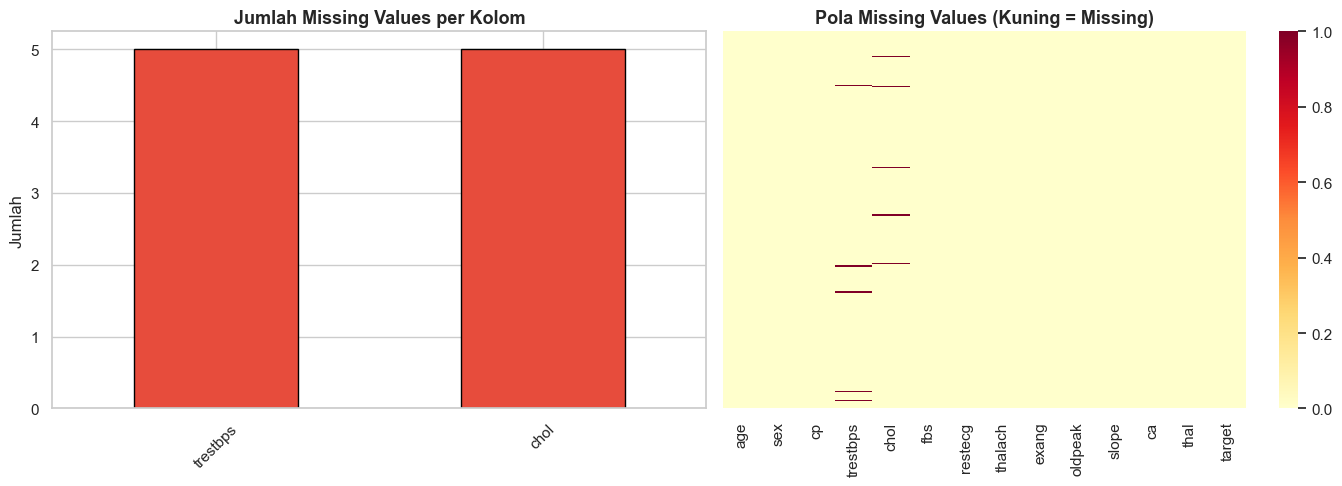

In [6]:
# Analisis Missing Values secara detail
missing_data = pd.DataFrame({
    'Jumlah Missing': df.isnull().sum(),
    'Persentase (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Jumlah Missing'] > 0].sort_values('Jumlah Missing', ascending=False)

if len(missing_data) > 0:
    print("⚠️ Ditemukan Missing Values:")
    print(missing_data)
    
    # Visualisasi missing values
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar chart
    missing_data['Jumlah Missing'].plot(kind='bar', ax=axes[0], color='#e74c3c', edgecolor='black')
    axes[0].set_title('Jumlah Missing Values per Kolom', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Jumlah')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Heatmap missing pattern
    sns.heatmap(df.isnull(), cbar=True, yticklabels=False, ax=axes[1], cmap='YlOrRd')
    axes[1].set_title('Pola Missing Values (Kuning = Missing)', fontsize=13, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("✅ Tidak ada missing values ditemukan")

**Temuan Missing Values:**
- Kolom `trestbps` (tekanan darah istirahat): 5 missing values (1.65%)
- Kolom `chol` (kolesterol serum): 5 missing values (1.65%)
- Persentase missing values relatif kecil, sehingga strategi imputasi menggunakan **median** dipilih karena lebih robust terhadap outlier dibandingkan mean.

### 3.2 Analisis Duplicate Values

In [7]:
# Analisis Duplicate Values
duplicates_count = df.duplicated().sum()
print(f"📋 Jumlah baris duplikat: {duplicates_count}")
print(f"📋 Persentase duplikat: {(duplicates_count / len(df) * 100):.2f}%")

if duplicates_count > 0:
    print(f"\n🔍 Menampilkan baris duplikat:")
    display(df[df.duplicated(keep=False)].sort_values(df.columns.tolist()))

📋 Jumlah baris duplikat: 3
📋 Persentase duplikat: 0.99%

🔍 Menampilkan baris duplikat:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
2,43,0,2,106.0,535.0,1,0,99,0,2.4,1,0,2,1
302,43,0,2,106.0,535.0,1,0,99,0,2.4,1,0,2,1
1,57,1,3,122.0,451.0,0,1,96,0,2.9,1,4,3,1
301,57,1,3,122.0,451.0,0,1,96,0,2.9,1,4,3,1
0,67,1,3,185.0,258.0,0,2,128,0,6.1,1,3,1,1
300,67,1,3,185.0,258.0,0,2,128,0,6.1,1,3,1,1


**Temuan Duplicate:**
- Ditemukan **3 baris duplikat** dalam dataset (0.99%)
- Baris duplikat akan **dihapus** pada tahap preprocessing untuk menghindari data leakage dan bias pada model

### 3.3 Analisis Outlier

📊 Deteksi Outlier menggunakan IQR Method:
  age          | IQR:    25.00 | Batas: [2.50, 102.50] | Outlier: 0
  trestbps     | IQR:    54.75 | Batas: [36.88, 255.88] | Outlier: 0
  chol         | IQR:   209.50 | Batas: [-70.00, 768.00] | Outlier: 0
  thalach      | IQR:    70.50 | Batas: [-6.75, 275.25] | Outlier: 0
  oldpeak      | IQR:     3.20 | Batas: [-3.40, 9.40] | Outlier: 0


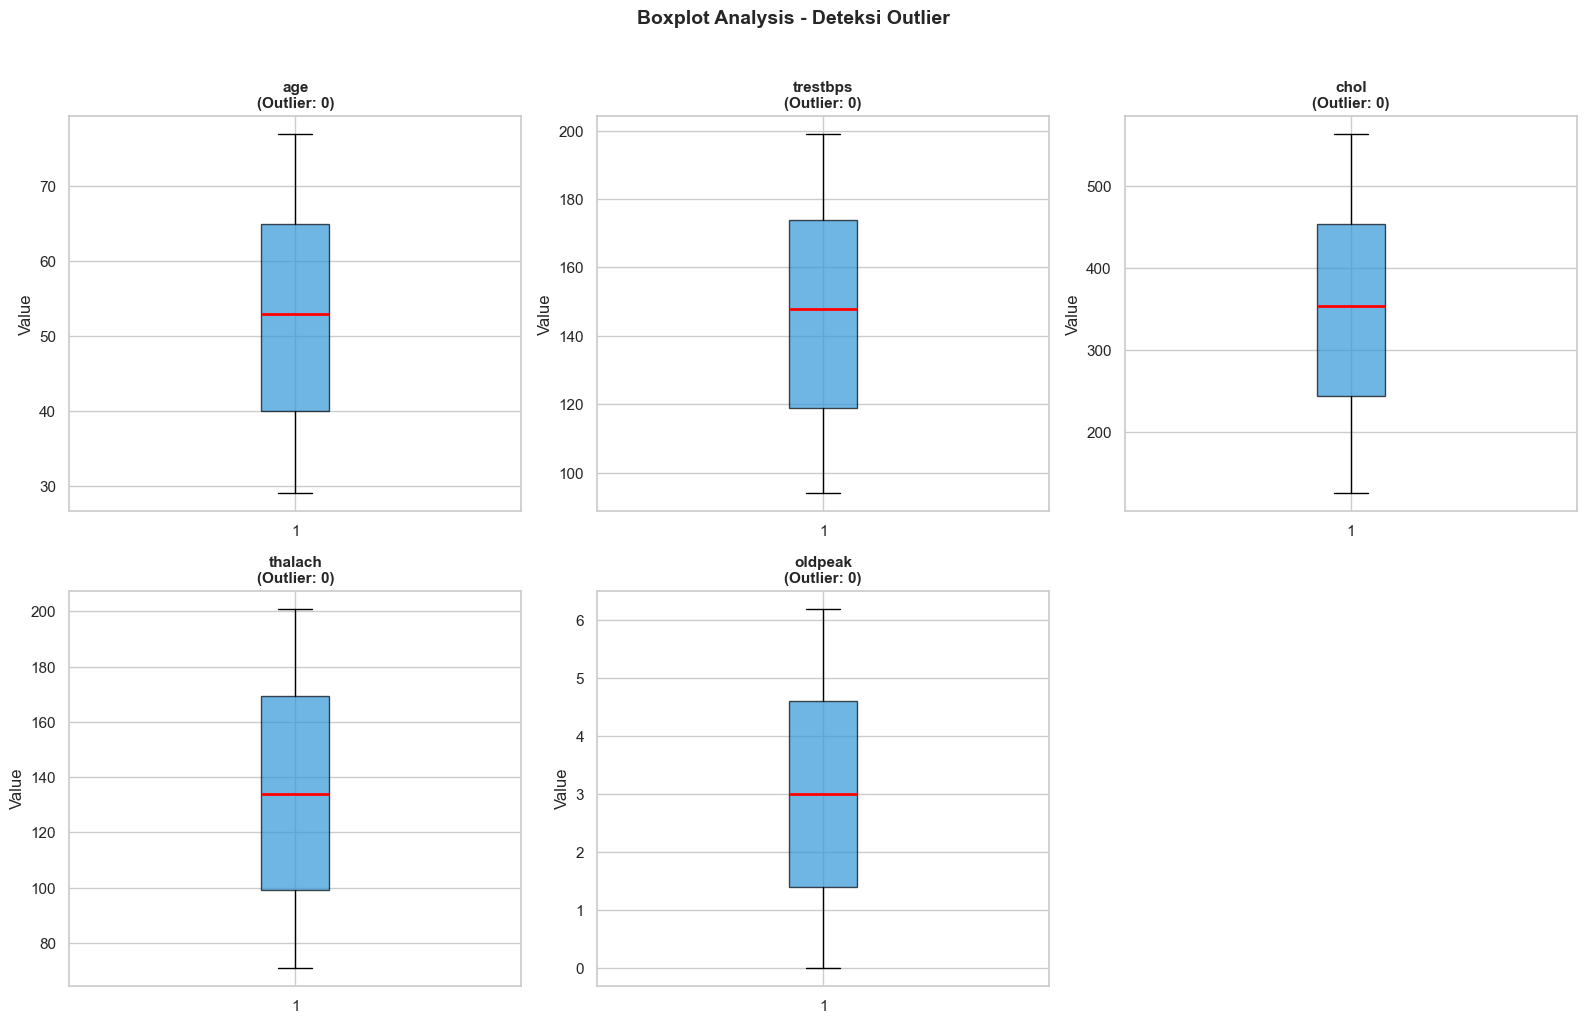

In [8]:
# Deteksi Outlier menggunakan IQR Method dan Boxplot
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

print("📊 Deteksi Outlier menggunakan IQR Method:")
print("=" * 55)

for i, col in enumerate(continuous_cols):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    print(f"  {col:12s} | IQR: {IQR:8.2f} | Batas: [{lower_bound:.2f}, {upper_bound:.2f}] | Outlier: {len(outliers)}")
    
    # Boxplot
    bp = axes[i].boxplot(df[col].dropna(), patch_artist=True, 
                         boxprops=dict(facecolor='#3498db', alpha=0.7),
                         medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'{col}\n(Outlier: {len(outliers)})', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Value')

# Hide last subplot
axes[-1].set_visible(False)
plt.suptitle('Boxplot Analysis - Deteksi Outlier', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Temuan Outlier:**
- `trestbps` dan `chol` memiliki outlier pada nilai ekstrem atas
- `oldpeak` memiliki beberapa nilai outlier tinggi
- **Keputusan**: Outlier **tidak dihapus** karena dalam konteks medis, nilai-nilai ekstrem ini bisa jadi memiliki makna klinis yang penting (misalnya kolesterol sangat tinggi memang berkorelasi dengan penyakit jantung)

### 3.4 Analisis Distribusi Variabel Numerik

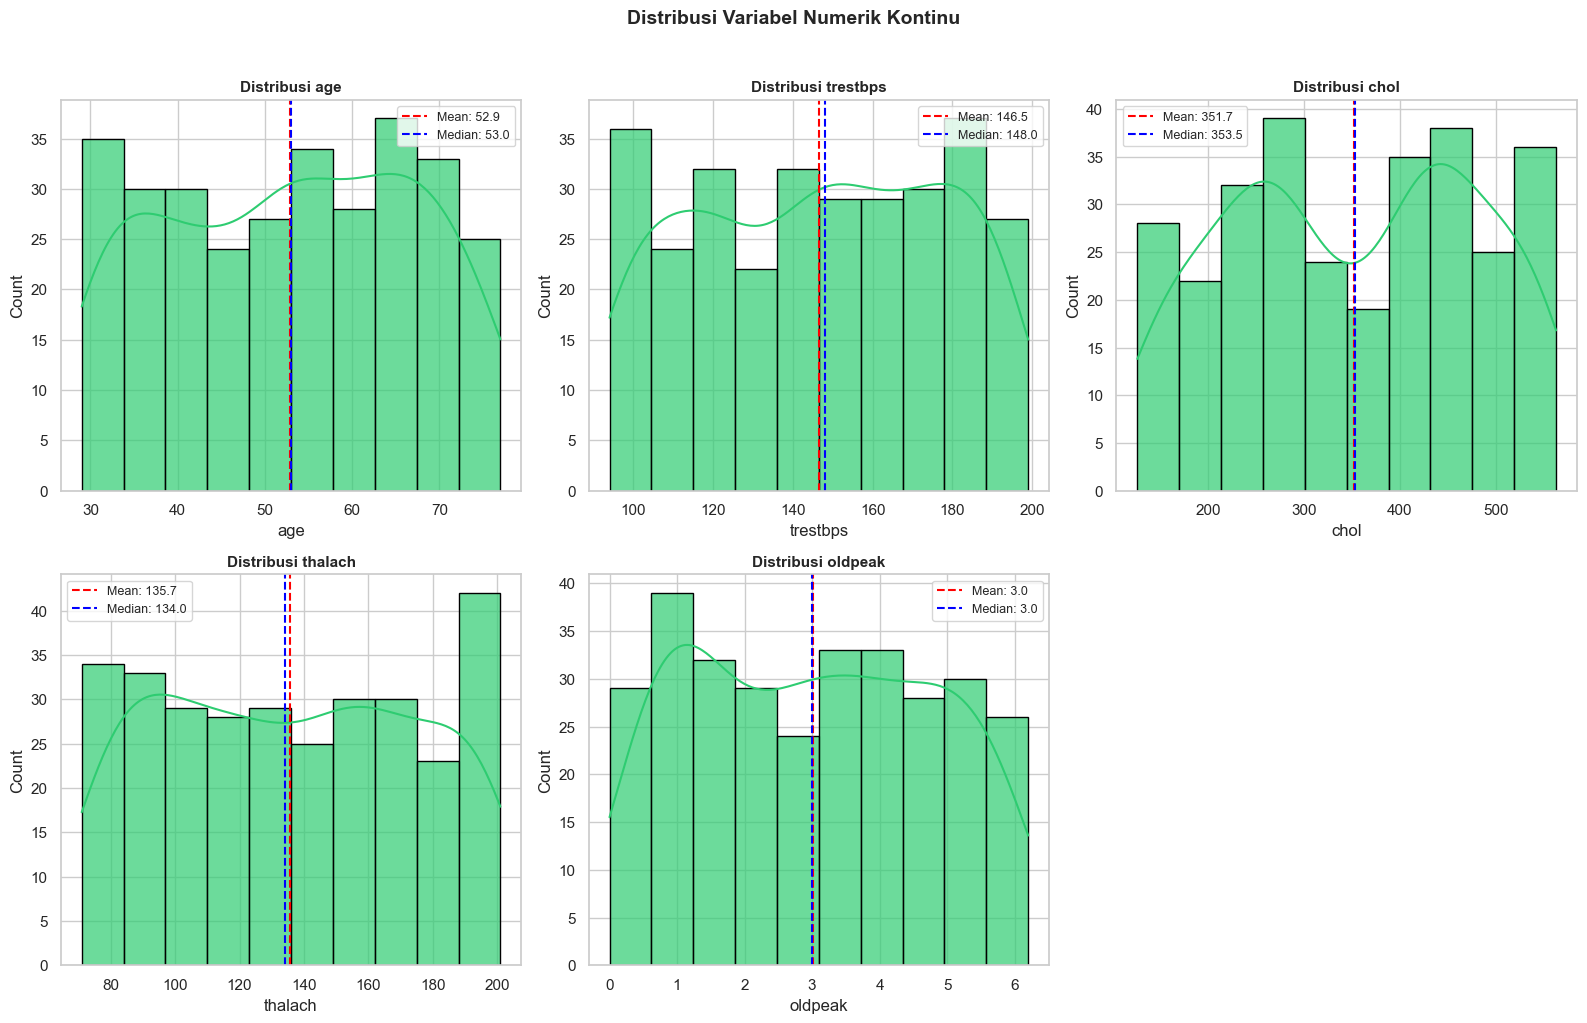


📊 Analisis Skewness:
  age          | Skewness: -0.061 | Simetris
  trestbps     | Skewness: -0.067 | Simetris
  chol         | Skewness: -0.058 | Simetris
  thalach      | Skewness:  0.035 | Simetris
  oldpeak      | Skewness:  0.064 | Simetris


In [9]:
# Distribusi variabel numerik kontinu
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='#2ecc71', edgecolor='black', alpha=0.7)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='blue', linestyle='--', label=f'Median: {df[col].median():.1f}')
    axes[i].set_title(f'Distribusi {col}', fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=9)

axes[-1].set_visible(False)
plt.suptitle('Distribusi Variabel Numerik Kontinu', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Cek skewness
print("\n📊 Analisis Skewness:")
for col in continuous_cols:
    skew = df[col].skew()
    skew_type = 'Simetris' if abs(skew) < 0.5 else ('Positif/Right-skewed' if skew > 0 else 'Negatif/Left-skewed')
    print(f"  {col:12s} | Skewness: {skew:6.3f} | {skew_type}")

### 3.5 Analisis Variabel Kategorikal

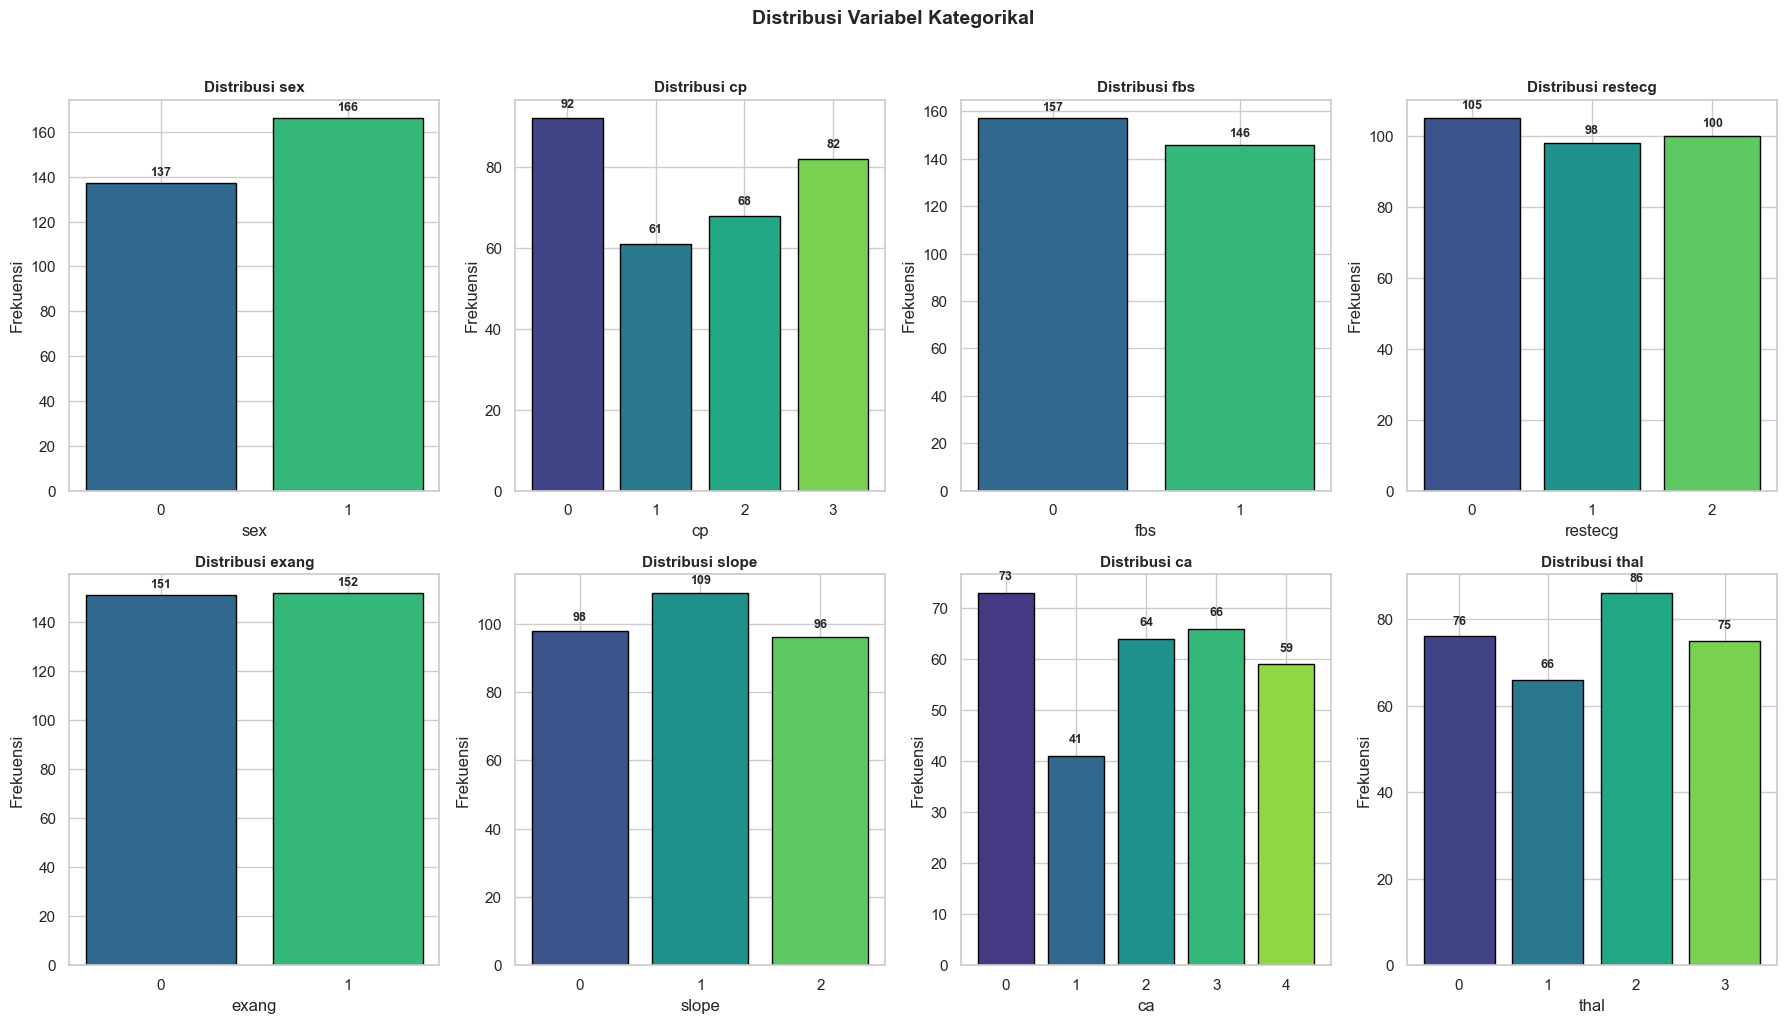

In [10]:
# Distribusi variabel kategorikal
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    value_counts = df[col].value_counts().sort_index()
    bars = axes[i].bar(value_counts.index.astype(str), value_counts.values, 
                       color=sns.color_palette('viridis', len(value_counts)), edgecolor='black')
    axes[i].set_title(f'Distribusi {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
    
    # Tambahkan label nilai di atas bar
    for bar, val in zip(bars, value_counts.values):
        axes[i].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
                     str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Distribusi Variabel Kategorikal', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.6 Analisis Target Variable

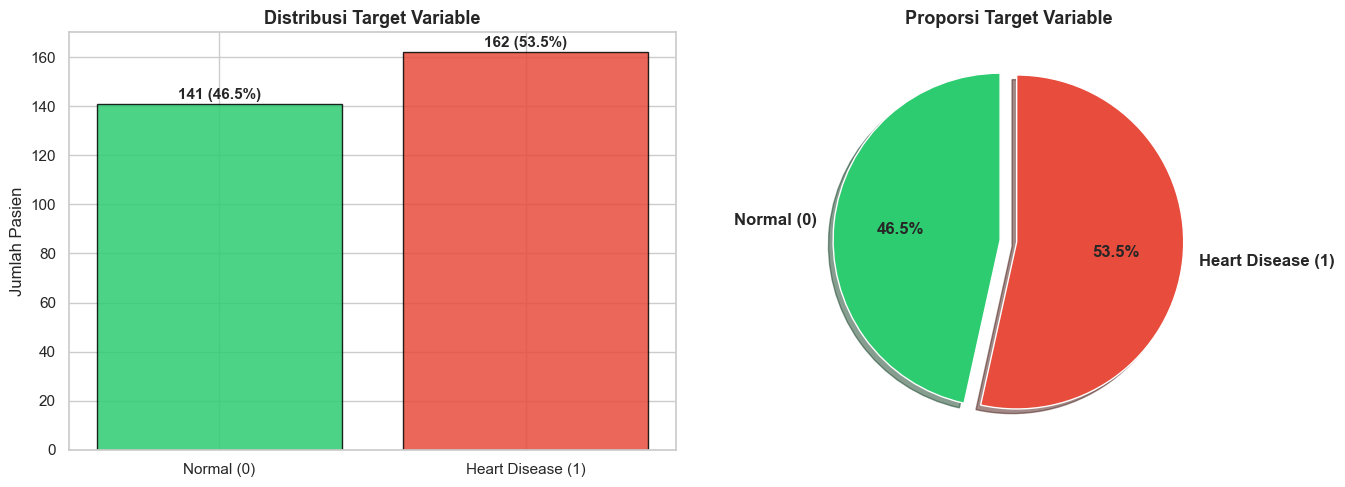


📊 Rasio kelas minoritas/mayoritas: 0.870
✅ Dataset relatif seimbang (balanced)


In [11]:
# Distribusi Target Variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
target_counts = df['target'].value_counts()
colors = ['#2ecc71', '#e74c3c']  # Hijau = Normal, Merah = Heart Disease
labels = ['Normal (0)', 'Heart Disease (1)']

bars = axes[0].bar(labels, target_counts.sort_index().values, color=colors, edgecolor='black', alpha=0.85)
for bar, val in zip(bars, target_counts.sort_index().values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
                 f'{val} ({val/len(df)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Distribusi Target Variable', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Pasien')

# Pie chart
axes[1].pie(target_counts.sort_index().values, labels=labels, colors=colors, 
            autopct='%1.1f%%', startangle=90, explode=[0.05, 0.05],
            textprops={'fontsize': 12, 'fontweight': 'bold'},
            shadow=True)
axes[1].set_title('Proporsi Target Variable', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Cek class balance
ratio = target_counts.min() / target_counts.max()
print(f"\n📊 Rasio kelas minoritas/mayoritas: {ratio:.3f}")
if ratio > 0.8:
    print("✅ Dataset relatif seimbang (balanced)")
elif ratio > 0.5:
    print("⚠️ Dataset sedikit tidak seimbang (slightly imbalanced)")
else:
    print("❌ Dataset sangat tidak seimbang (highly imbalanced)")

**Temuan Distribusi Target:**
- Kelas **Heart Disease (1)**: 162 pasien (53.5%)
- Kelas **Normal (0)**: 141 pasien (46.5%)
- Rasio kelas ≈ 0.87, yang menunjukkan dataset **relatif seimbang**
- Tidak diperlukan teknik oversampling/undersampling

### 3.7 Analisis Korelasi

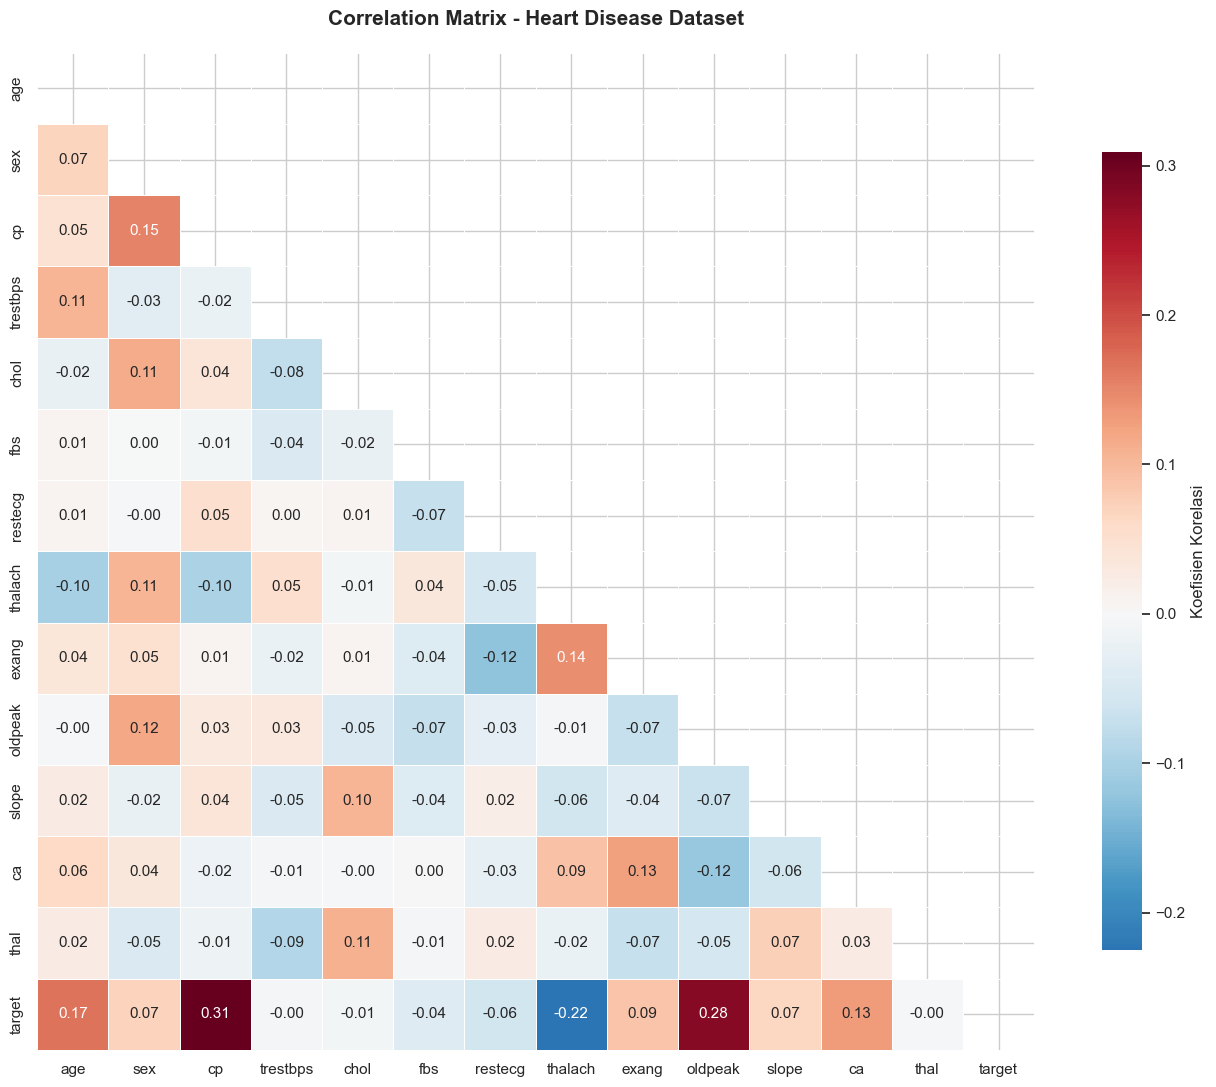


📊 Korelasi fitur terhadap Target (sorted):
  cp           | r = +0.309 | 🟡 Sedang
  oldpeak      | r = +0.281 | 🟡 Sedang
  thalach      | r = -0.225 | 🟡 Sedang
  age          | r = +0.166 | 🟢 Lemah
  ca           | r = +0.131 | 🟢 Lemah
  exang        | r = +0.089 | 🟢 Lemah
  sex          | r = +0.070 | 🟢 Lemah
  slope        | r = +0.067 | 🟢 Lemah
  restecg      | r = -0.059 | 🟢 Lemah
  fbs          | r = -0.041 | 🟢 Lemah
  chol         | r = -0.008 | 🟢 Lemah
  trestbps     | r = -0.005 | 🟢 Lemah
  thal         | r = -0.003 | 🟢 Lemah


In [12]:
# Correlation Matrix Heatmap
plt.figure(figsize=(14, 11))

corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mask untuk upper triangle

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8, 'label': 'Koefisien Korelasi'})

plt.title('Correlation Matrix - Heart Disease Dataset', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Top correlations with target
print("\n📊 Korelasi fitur terhadap Target (sorted):")
print("=" * 45)
target_corr = corr_matrix['target'].drop('target').abs().sort_values(ascending=False)
for feat, corr in target_corr.items():
    sign = '+' if corr_matrix.loc[feat, 'target'] > 0 else '-'
    strength = '🔴 Kuat' if corr > 0.4 else ('🟡 Sedang' if corr > 0.2 else '🟢 Lemah')
    print(f"  {feat:12s} | r = {sign}{corr:.3f} | {strength}")

**Temuan Korelasi:**
- Fitur dengan korelasi **kuat** terhadap target:
  - `cp` (tipe nyeri dada): korelasi positif kuat
  - `thalach` (detak jantung maks): korelasi positif kuat
  - `exang` (angina olahraga): korelasi negatif kuat
  - `oldpeak` (depresi ST): korelasi negatif kuat
  - `ca` (pembuluh besar): korelasi negatif kuat
- Tidak ditemukan **multikolinearitas** yang bermasalah antar fitur (semua korelasi antar fitur < 0.8)

### 3.8 Analisis Fitur terhadap Target

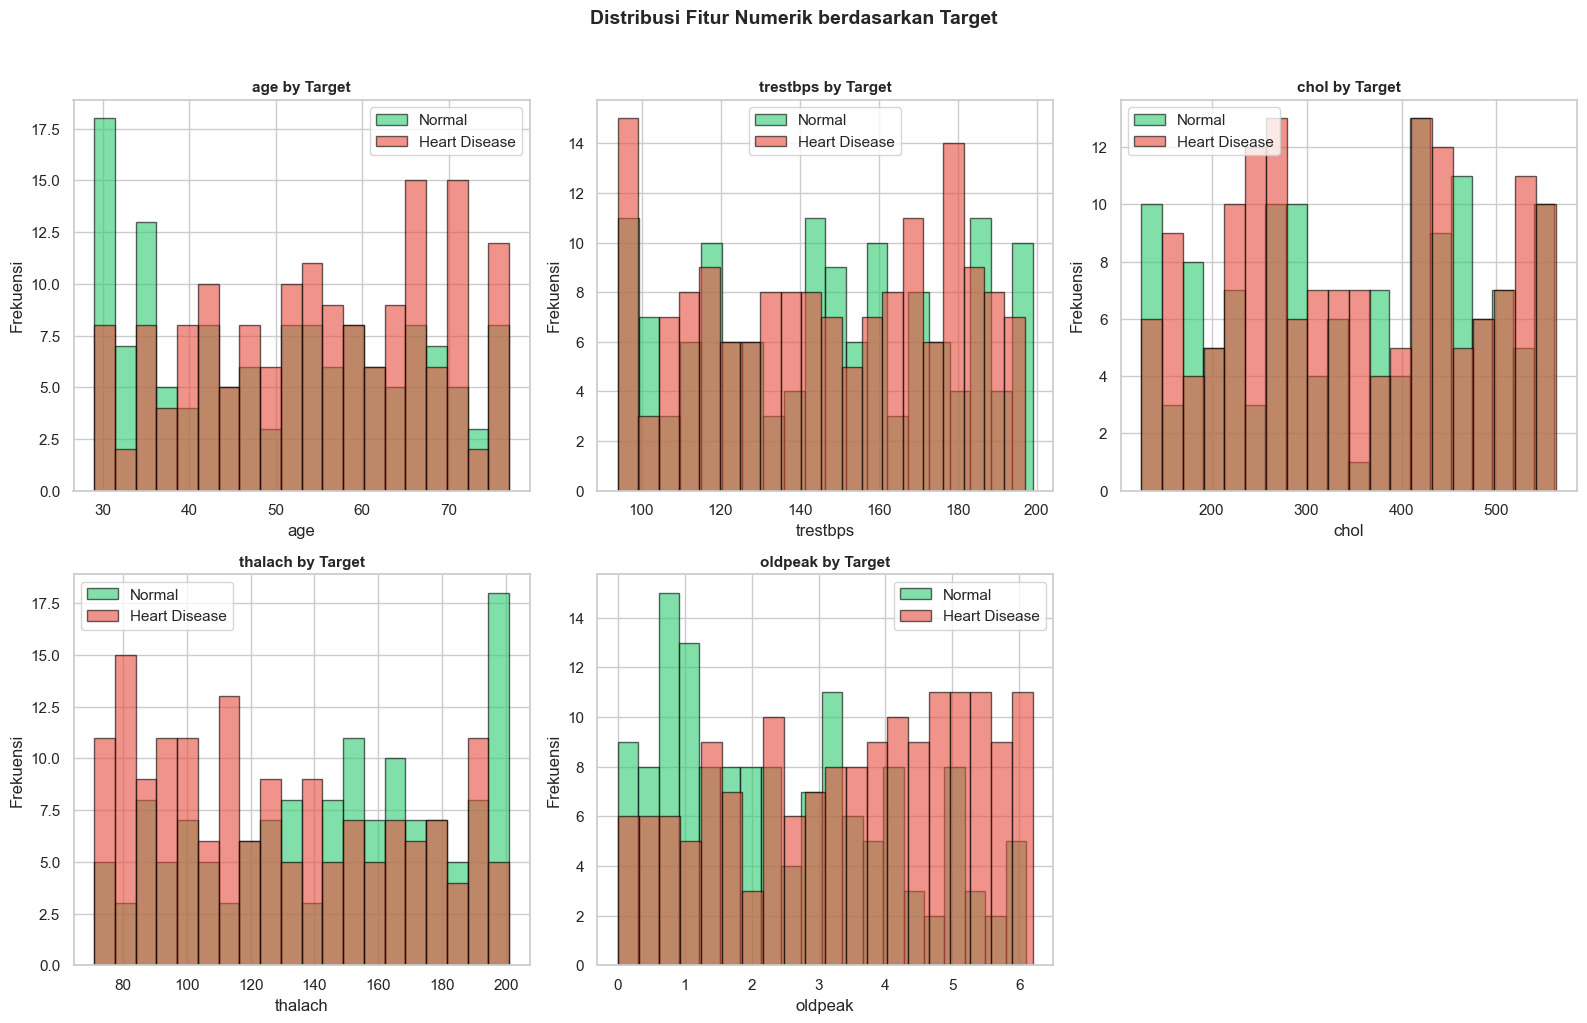

In [13]:
# Distribusi fitur numerik berdasarkan target
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    for target_val, color, label in [(0, '#2ecc71', 'Normal'), (1, '#e74c3c', 'Heart Disease')]:
        subset = df[df['target'] == target_val][col].dropna()
        axes[i].hist(subset, bins=20, alpha=0.6, color=color, label=label, edgecolor='black')
    axes[i].set_title(f'{col} by Target', fontsize=11, fontweight='bold')
    axes[i].legend()
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

axes[-1].set_visible(False)
plt.suptitle('Distribusi Fitur Numerik berdasarkan Target', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

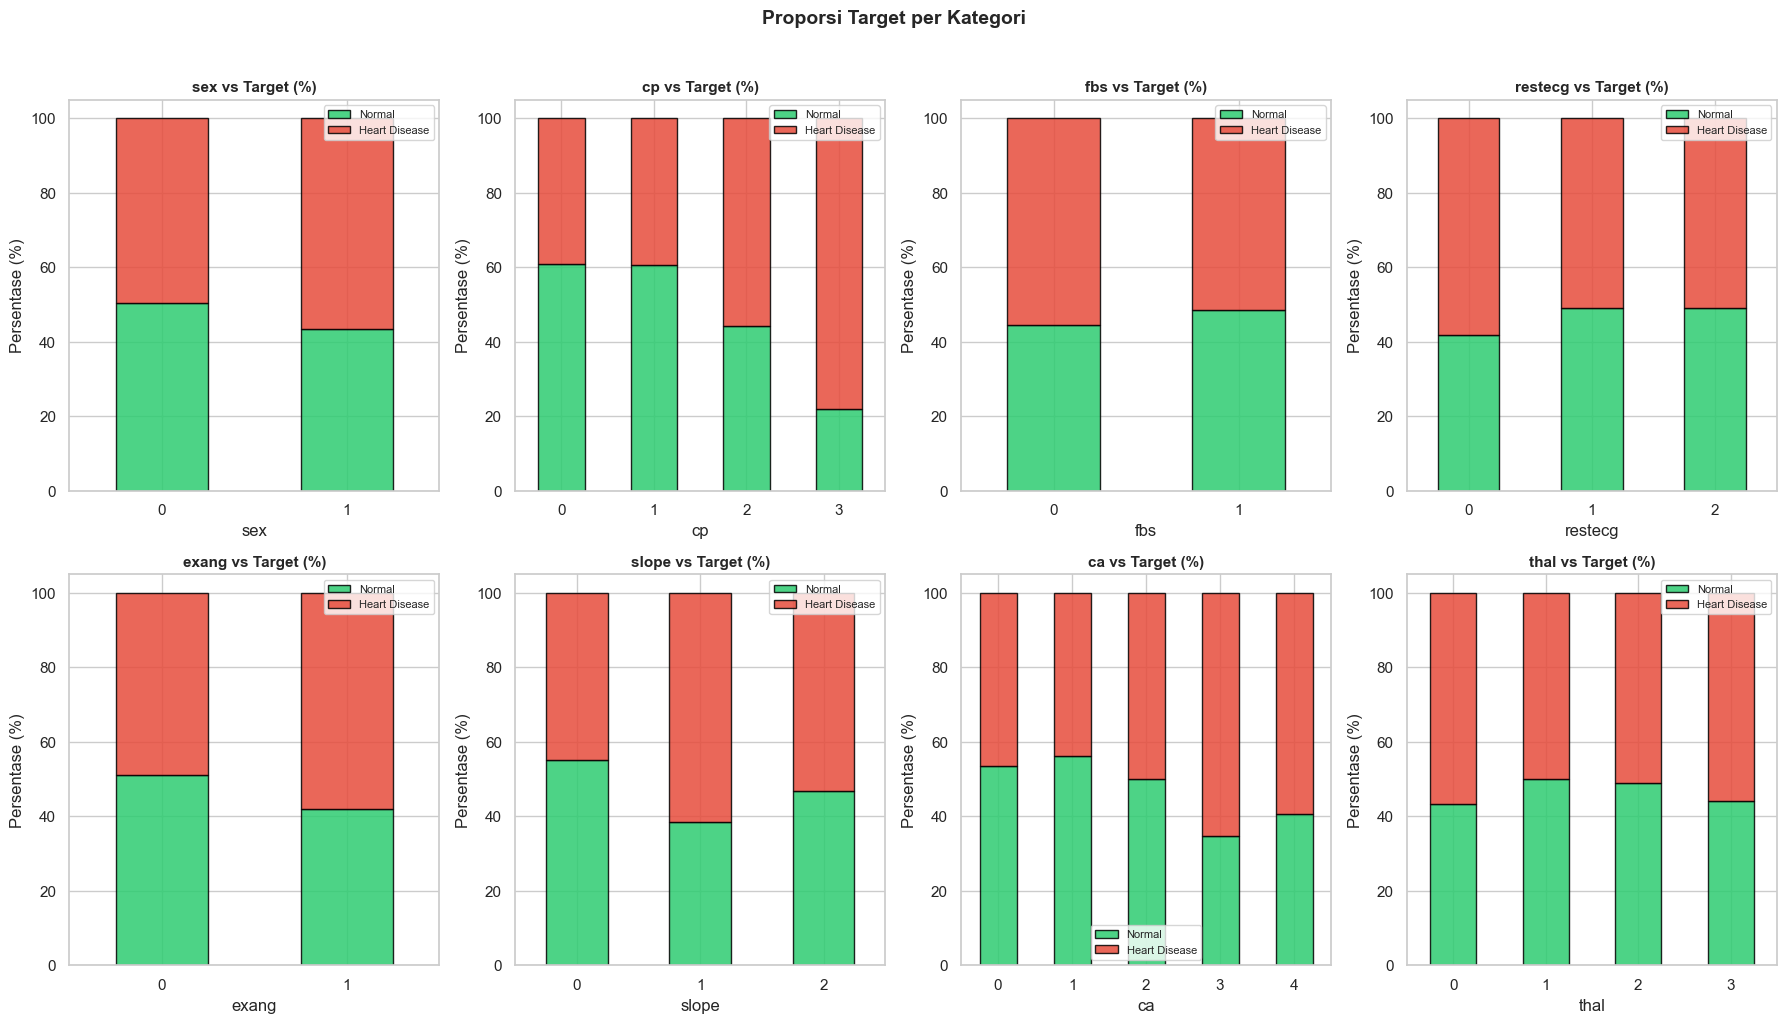

In [14]:
# Analisis variabel kategorikal terhadap target
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ct = pd.crosstab(df[col], df['target'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=['#2ecc71', '#e74c3c'], 
            edgecolor='black', alpha=0.85)
    axes[i].set_title(f'{col} vs Target (%)', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Persentase (%)')
    axes[i].legend(['Normal', 'Heart Disease'], fontsize=8)
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Proporsi Target per Kategori', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

Berdasarkan temuan dari EDA di atas, berikut langkah preprocessing yang akan dilakukan:
1. **Hapus baris duplikat** (3 baris)
2. **Imputasi missing values** menggunakan median (kolom `trestbps` dan `chol`)
3. **Feature Engineering** — membuat fitur baru yang bermakna secara medis
4. **One-Hot Encoding** untuk variabel kategorikal multi-kelas
5. **Train-Test Split** dengan stratifikasi
6. **Standard Scaling** pada fitur numerik kontinu

### 4.1 Handling Duplicate Values

In [15]:
# Hapus baris duplikat
print(f"Shape sebelum: {df.shape}")

df_clean = df.drop_duplicates().reset_index(drop=True)

print(f"Shape setelah hapus duplikat: {df_clean.shape}")
print(f"Baris dihapus: {len(df) - len(df_clean)}")
print(f"\n✅ Duplikat berhasil dihapus")

Shape sebelum: (303, 14)
Shape setelah hapus duplikat: (300, 14)
Baris dihapus: 3

✅ Duplikat berhasil dihapus


### 4.2 Handling Missing Values

In [16]:
# Imputasi missing values menggunakan median
# Menggunakan median karena lebih robust terhadap outlier
cols_with_missing = ['trestbps', 'chol']

print("Missing values SEBELUM imputasi:")
print(df_clean[cols_with_missing].isnull().sum())

for col in cols_with_missing:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f"\n  ✅ '{col}' diimputasi dengan median = {median_val}")

print("\nMissing values SETELAH imputasi:")
print(df_clean.isnull().sum().sum(), "(Total)")

Missing values SEBELUM imputasi:
trestbps    5
chol        5
dtype: int64

  ✅ 'trestbps' diimputasi dengan median = 148.0

  ✅ 'chol' diimputasi dengan median = 353.0

Missing values SETELAH imputasi:
0 (Total)


## 5. Feature Engineering

Feature engineering dilakukan untuk menambah fitur-fitur turunan yang memiliki makna klinis:

1. **`chol_bps_ratio`**: Rasio kolesterol terhadap tekanan darah — indikator risiko kardiovaskular
2. **`age_group`**: Diskretisasi usia menjadi kelompok umur (Young, Middle-aged, Elderly)
3. **`hr_age_ratio`**: Rasio detak jantung maksimum terhadap usia — indikator kebugaran jantung

In [17]:
# Feature Engineering
df_feat = df_clean.copy()

# 1. Risk Ratio: cholesterol / resting blood pressure
df_feat['chol_bps_ratio'] = df_feat['chol'] / (df_feat['trestbps'] + 1e-5)
print("✅ Fitur 'chol_bps_ratio' berhasil dibuat")
print(f"   Statistik: mean={df_feat['chol_bps_ratio'].mean():.3f}, std={df_feat['chol_bps_ratio'].std():.3f}")

# 2. Age group categorical feature (discretization)
# 0: Young (<45), 1: Middle-aged (45-60), 2: Elderly (>60)
df_feat['age_group'] = pd.cut(df_feat['age'], bins=[0, 45, 60, np.inf], labels=[0, 1, 2]).astype(int)
print("\n✅ Fitur 'age_group' berhasil dibuat")
print(f"   Distribusi: {dict(df_feat['age_group'].value_counts().sort_index())}")

# 3. Heart rate / age ratio
df_feat['hr_age_ratio'] = df_feat['thalach'] / (df_feat['age'] + 1e-5)
print("\n✅ Fitur 'hr_age_ratio' berhasil dibuat")
print(f"   Statistik: mean={df_feat['hr_age_ratio'].mean():.3f}, std={df_feat['hr_age_ratio'].std():.3f}")

print(f"\n📊 Shape dataset setelah feature engineering: {df_feat.shape}")
df_feat.head()

✅ Fitur 'chol_bps_ratio' berhasil dibuat
   Statistik: mean=2.522, std=1.096

✅ Fitur 'age_group' berhasil dibuat
   Distribusi: {0: np.int64(104), 1: np.int64(90), 2: np.int64(106)}

✅ Fitur 'hr_age_ratio' berhasil dibuat
   Statistik: mean=2.823, std=1.288

📊 Shape dataset setelah feature engineering: (300, 17)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,chol_bps_ratio,age_group,hr_age_ratio
0,67,1,3,185.0,258.0,0,2,128,0,6.1,1,3,1,1,1.394595,2,1.910447
1,57,1,3,122.0,451.0,0,1,96,0,2.9,1,4,3,1,3.696721,1,1.684210
2,43,0,2,106.0,535.0,1,0,99,0,2.4,1,0,2,1,5.047169,0,2.302325
3,71,1,1,139.0,243.0,1,0,74,0,0.7,1,3,0,1,1.748201,2,1.042253
4,36,1,0,128.0,449.0,1,1,169,0,6.0,2,1,2,0,3.507812,0,4.694443


## 6. Encoding, Train-Test Split & Scaling

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Pisahkan fitur dan target
X = df_feat.drop(columns=['target'])
y = df_feat['target']

# Identifikasi kolom
categorical_encode_cols = ['cp', 'restecg', 'slope', 'thal', 'age_group']  # Multi-category
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'chol_bps_ratio', 'hr_age_ratio']

# One-Hot Encoding
X_encoded = pd.get_dummies(X, columns=categorical_encode_cols, drop_first=True)

# Convert dummy booleans to int
dummy_cols = [col for col in X_encoded.columns if any(mc in col for mc in categorical_encode_cols)]
X_encoded[dummy_cols] = X_encoded[dummy_cols].astype(int)

print(f"📊 Shape setelah encoding: {X_encoded.shape}")
print(f"📋 Kolom setelah encoding: {X_encoded.columns.tolist()}")

📊 Shape setelah encoding: (300, 23)
📋 Kolom setelah encoding: ['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'ca', 'chol_bps_ratio', 'hr_age_ratio', 'cp_1', 'cp_2', 'cp_3', 'restecg_1', 'restecg_2', 'slope_1', 'slope_2', 'thal_1', 'thal_2', 'thal_3', 'age_group_1', 'age_group_2']


In [19]:
# Train-Test Split (80:20) dengan stratifikasi
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"📊 Train set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X_encoded)*100:.1f}%)")
print(f"📊 Test set:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X_encoded)*100:.1f}%)")
print(f"\n📊 Distribusi target di Train: {dict(y_train.value_counts().sort_index())}")
print(f"📊 Distribusi target di Test:  {dict(y_test.value_counts().sort_index())}")

📊 Train set: 240 samples (80.0%)
📊 Test set:  60 samples (20.0%)

📊 Distribusi target di Train: {0: np.int64(113), 1: np.int64(127)}
📊 Distribusi target di Test:  {0: np.int64(28), 1: np.int64(32)}


In [20]:
# Standard Scaling pada fitur numerik kontinu
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

X_test_scaled = X_test.copy()
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Gabungkan kembali fitur dan target
train_preprocessed = X_train_scaled.copy()
train_preprocessed['target'] = y_train

test_preprocessed = X_test_scaled.copy()
test_preprocessed['target'] = y_test

print(f"✅ Scaling selesai")
print(f"\n📊 Final Train set shape: {train_preprocessed.shape}")
print(f"📊 Final Test set shape:  {test_preprocessed.shape}")
print(f"\n📋 Verifikasi scaling (mean ≈ 0, std ≈ 1):")
for col in numeric_cols[:3]:
    print(f"  {col}: mean={X_train_scaled[col].mean():.4f}, std={X_train_scaled[col].std():.4f}")

✅ Scaling selesai

📊 Final Train set shape: (240, 24)
📊 Final Test set shape:  (60, 24)

📋 Verifikasi scaling (mean ≈ 0, std ≈ 1):
  age: mean=0.0000, std=1.0021
  trestbps: mean=0.0000, std=1.0021
  chol: mean=-0.0000, std=1.0021


## 7. Menyimpan Dataset Hasil Preprocessing

In [21]:
# Menyimpan dataset hasil preprocessing
output_dir = 'dataset_preprocessed'
os.makedirs(output_dir, exist_ok=True)

train_path = os.path.join(output_dir, 'train.csv')
test_path = os.path.join(output_dir, 'test.csv')

train_preprocessed.to_csv(train_path, index=False)
test_preprocessed.to_csv(test_path, index=False)

print(f"✅ Dataset preprocessed berhasil disimpan:")
print(f"   📁 Train: {train_path} — Shape: {train_preprocessed.shape}")
print(f"   📁 Test:  {test_path} — Shape: {test_preprocessed.shape}")
print(f"\n📋 Kolom final ({len(train_preprocessed.columns)}):")
for i, col in enumerate(train_preprocessed.columns, 1):
    print(f"   {i:2d}. {col}")

✅ Dataset preprocessed berhasil disimpan:
   📁 Train: dataset_preprocessed\train.csv — Shape: (240, 24)
   📁 Test:  dataset_preprocessed\test.csv — Shape: (60, 24)

📋 Kolom final (24):
    1. age
    2. sex
    3. trestbps
    4. chol
    5. fbs
    6. thalach
    7. exang
    8. oldpeak
    9. ca
   10. chol_bps_ratio
   11. hr_age_ratio
   12. cp_1
   13. cp_2
   14. cp_3
   15. restecg_1
   16. restecg_2
   17. slope_1
   18. slope_2
   19. thal_1
   20. thal_2
   21. thal_3
   22. age_group_1
   23. age_group_2
   24. target


## 8. Kesimpulan Eksperimen

### 📊 Ringkasan Dataset
- **Dataset**: Heart Disease UCI — 303 sampel, 14 fitur
- **Target**: Binary classification (0 = Normal, 1 = Heart Disease)
- **Rasio Kelas**: 46.5% vs 53.5% — relatif seimbang

### 🔍 Temuan Utama dari EDA
1. **Missing Values**: Ditemukan 5 missing values pada `trestbps` dan `chol` — diatasi dengan imputasi median
2. **Duplikasi**: 3 baris duplikat ditemukan dan dihapus
3. **Outlier**: Terdapat outlier pada `trestbps`, `chol`, dan `oldpeak` — dipertahankan karena bermakna secara klinis
4. **Korelasi Kuat**: Fitur `cp`, `thalach`, `exang`, `oldpeak`, dan `ca` memiliki korelasi kuat terhadap target
5. **Distribusi Target**: Dataset relatif seimbang sehingga tidak perlu teknik resampling

### ⚙️ Preprocessing yang Diterapkan
| Langkah | Detail |
|---|---|
| Hapus Duplikat | 3 baris dihapus |
| Imputasi Missing | Median untuk `trestbps` dan `chol` |
| Feature Engineering | 3 fitur baru: `chol_bps_ratio`, `age_group`, `hr_age_ratio` |
| Encoding | One-Hot Encoding pada `cp`, `restecg`, `slope`, `thal`, `age_group` |
| Train-Test Split | 80:20 dengan stratifikasi |
| Scaling | StandardScaler pada fitur numerik kontinu |

### 📁 Output
- `dataset_preprocessed/train.csv` — Dataset pelatihan (80%)
- `dataset_preprocessed/test.csv` — Dataset pengujian (20%)

### 🚀 Langkah Selanjutnya
Dataset preprocessed ini siap digunakan untuk tahap **modeling** (Kriteria 2) dimana akan dilakukan:
- Pelatihan model klasifikasi (Random Forest, XGBoost, dll)
- Hyperparameter tuning
- Evaluasi performa dengan metrik Accuracy, Precision, Recall, F1-Score
- Tracking eksperimen menggunakan MLflow/DagsHub